In [1]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json


In [2]:
a = 2
avg_len = 0.05
radius = 0.95

allowBending = False
useTFT = True
disableFusedRegionTFT = False
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [3]:
ipu, m, marker = pattern_generator_using_gmsh.get_three_star_hex(a, radius, num_spikes=3, avg_len_boundary = avg_len, avg_len_embeddings = avg_len)        

In [4]:
finalMarkers = np.where(np.array(marker) == 1)[0]

marker = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = marker, epsilon = 1e-9)


# finalMarkers = np.where(np.array(marker) == 1)[0]
# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= -1)
# m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= -1)

# fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

# ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

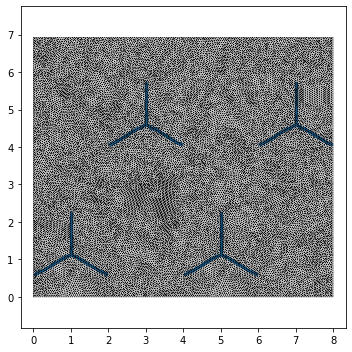

In [5]:
visualization.plot_2d_mesh(m, pointList = marker, width = 5, height = 5)

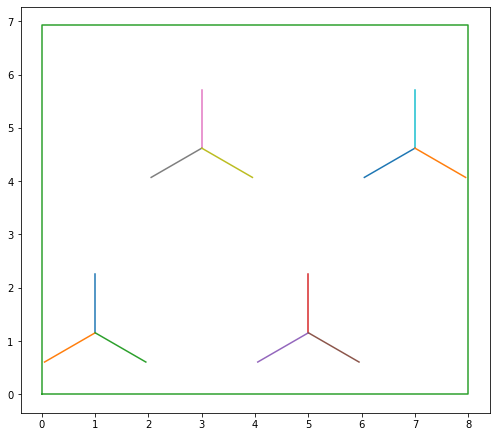

In [6]:
pts, edges, bpts, bedges = pattern_generator_using_gmsh.get_three_star_hex(a, radius, num_spikes=3, avg_len_boundary = avg_len, avg_len_embeddings = avg_len, return_line_segmnets=True)
new_points = list(pts) + list(bpts)
new_edges = list(edges) + list(bedges + len(pts))
visualization.plot_line_segments(new_points, np.array(new_edges) - 1)

In [7]:
viewer = TriMeshViewer(ipu, width=1024, height=1024)
viewer.showWireframe(False)
viewer.show()

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

In [8]:
def get_label(a, r):
    return "{:.2f}_{:.2f}".format(a, r)


In [9]:
import os

In [10]:
name = "isotropy_star"
time_stamp = time.strftime("%Y_%m_%d_%H_%M")
# time_stamp = "2023_10_25_14_54"
base_folder = 'output/{}/{}'.format(name, time_stamp)
    
result_folder = "{}/{}".format(base_folder, get_label(a, radius))
if not os.path.exists(result_folder):
    os.makedirs(result_folder)  
    
render_images = True
variable = get_label(a, radius)

In [11]:
ipu.sheet.pressure = 0.4

In [12]:
configure_solver_parallelism()

In [13]:
framerate = 5 # Update every 5 iterations
def cb(it):
    if it % framerate == 0:
        viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [14]:
hessianShiftForRigidMotion = 1e-10
hessianShiftForAlphainPlanar = 1e-12

In [15]:
fixedVars, hessianShift = [], hessianShiftForRigidMotion

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

In [16]:
opts.niter = 500
opts.gradTol = 1e-10

cr = inflation.inflation_newton(ipu, fixedVars, opts, callback=cb, hessianShift = hessianShift)

In [17]:
fixedVars, hessianShift = list(ipu.get_center_fixedVars()), hessianShiftForAlphainPlanar

In [18]:
opts.niter = 500
opts.gradTol = 1e-10

cr = inflation.inflation_newton(ipu, fixedVars, opts, callback=cb, hessianShift = hessianShift)

In [19]:
viewer.update()
viewer.showWireframe(False)

In [20]:
viewer.setCameraParams(((0.05388981383962801, -3.1668002724484476, 5.803170717118252),
 (-0.014947641421525739, 0.8776479009146649, 0.47907278156457567),
 (0.0, 0.0, 0.0)))

In [21]:
orender = viewer.offscreenRenderer(width=1024,height=1024)
# orender.meshes[0].setColor(C[mm.elements().ravel()])
orender.render()
orender.save("isotropic.png")

In [23]:
experiment_log = {}
experiment_log["Ipu simulation succeed"] = int(cr.success)
experiment_log["Simulation Kappa value"] = (ipu.getVars()[-2])
if np.abs(ipu.getVars()[-2]) > 1e-10:
    experiment_log["Planar equilibrium"] = 0
    print("Warning: Can not compute stiffness due to non-planar equilibrium!")
else:
    experiment_log["Planar equilibrium"] = 1

In [24]:
result_folder = 'output'
name = 'cosine_dash'
variable = 0
render_images = True

In [25]:
# Compute stiffness after removing the vertical offset
ipu.reparametrize_vertical_offset()
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getBendingStiffnessFixedVars(), opts, callback=cb, hessianShift = 0)
stiffness_values, sampled_alphas, stiffness_coefficient = visualize_sampled_bending_stiffness(ipu, 1000, optimizer, hessianShift = 1e-9, fixedVars = ipu.getBendingStiffnessFixedVars(), filename = "{}/stiffness_{}_{}.png".format(result_folder, name, variable), generate_images = render_images, plot_min_r=0)

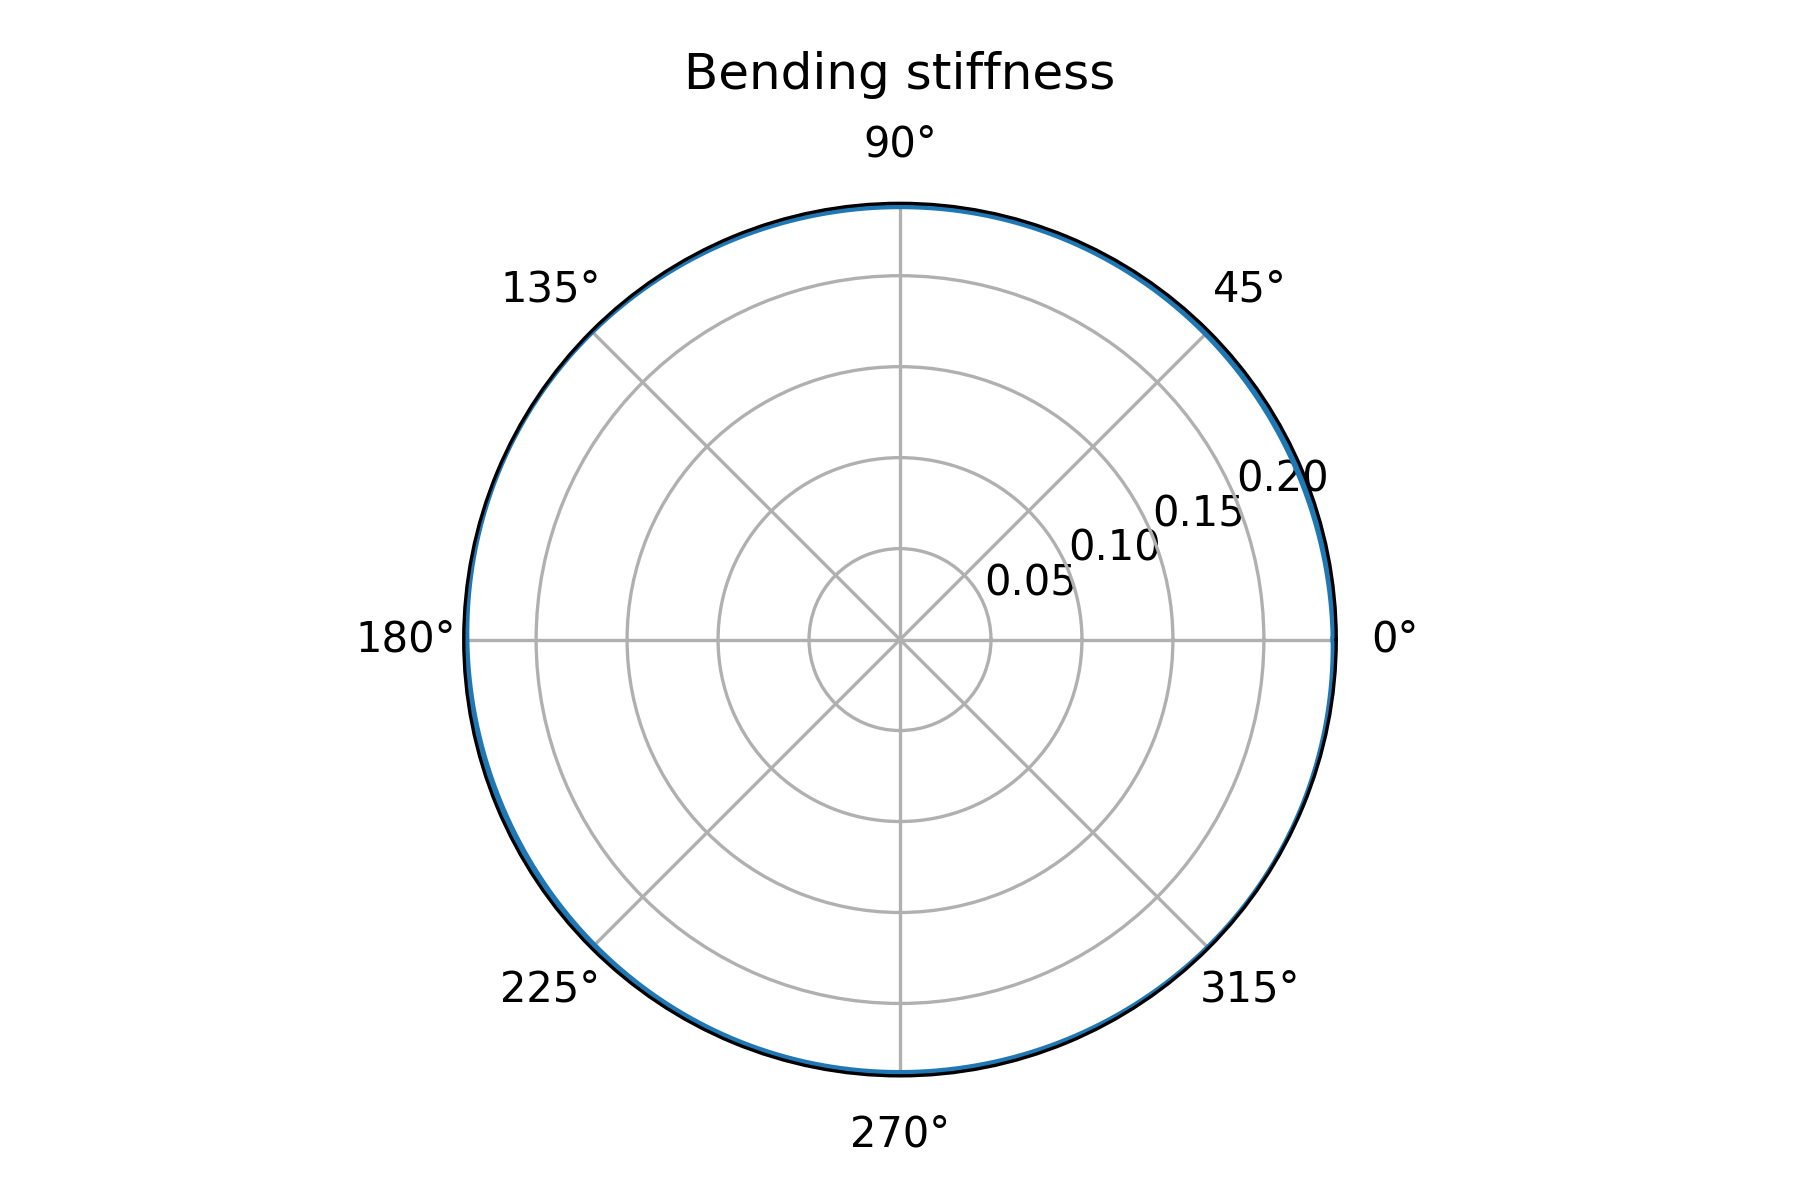

In [26]:
from IPython.display import Image
Image(filename="{}/stiffness_{}_{}.png".format(result_folder, name, variable)) 

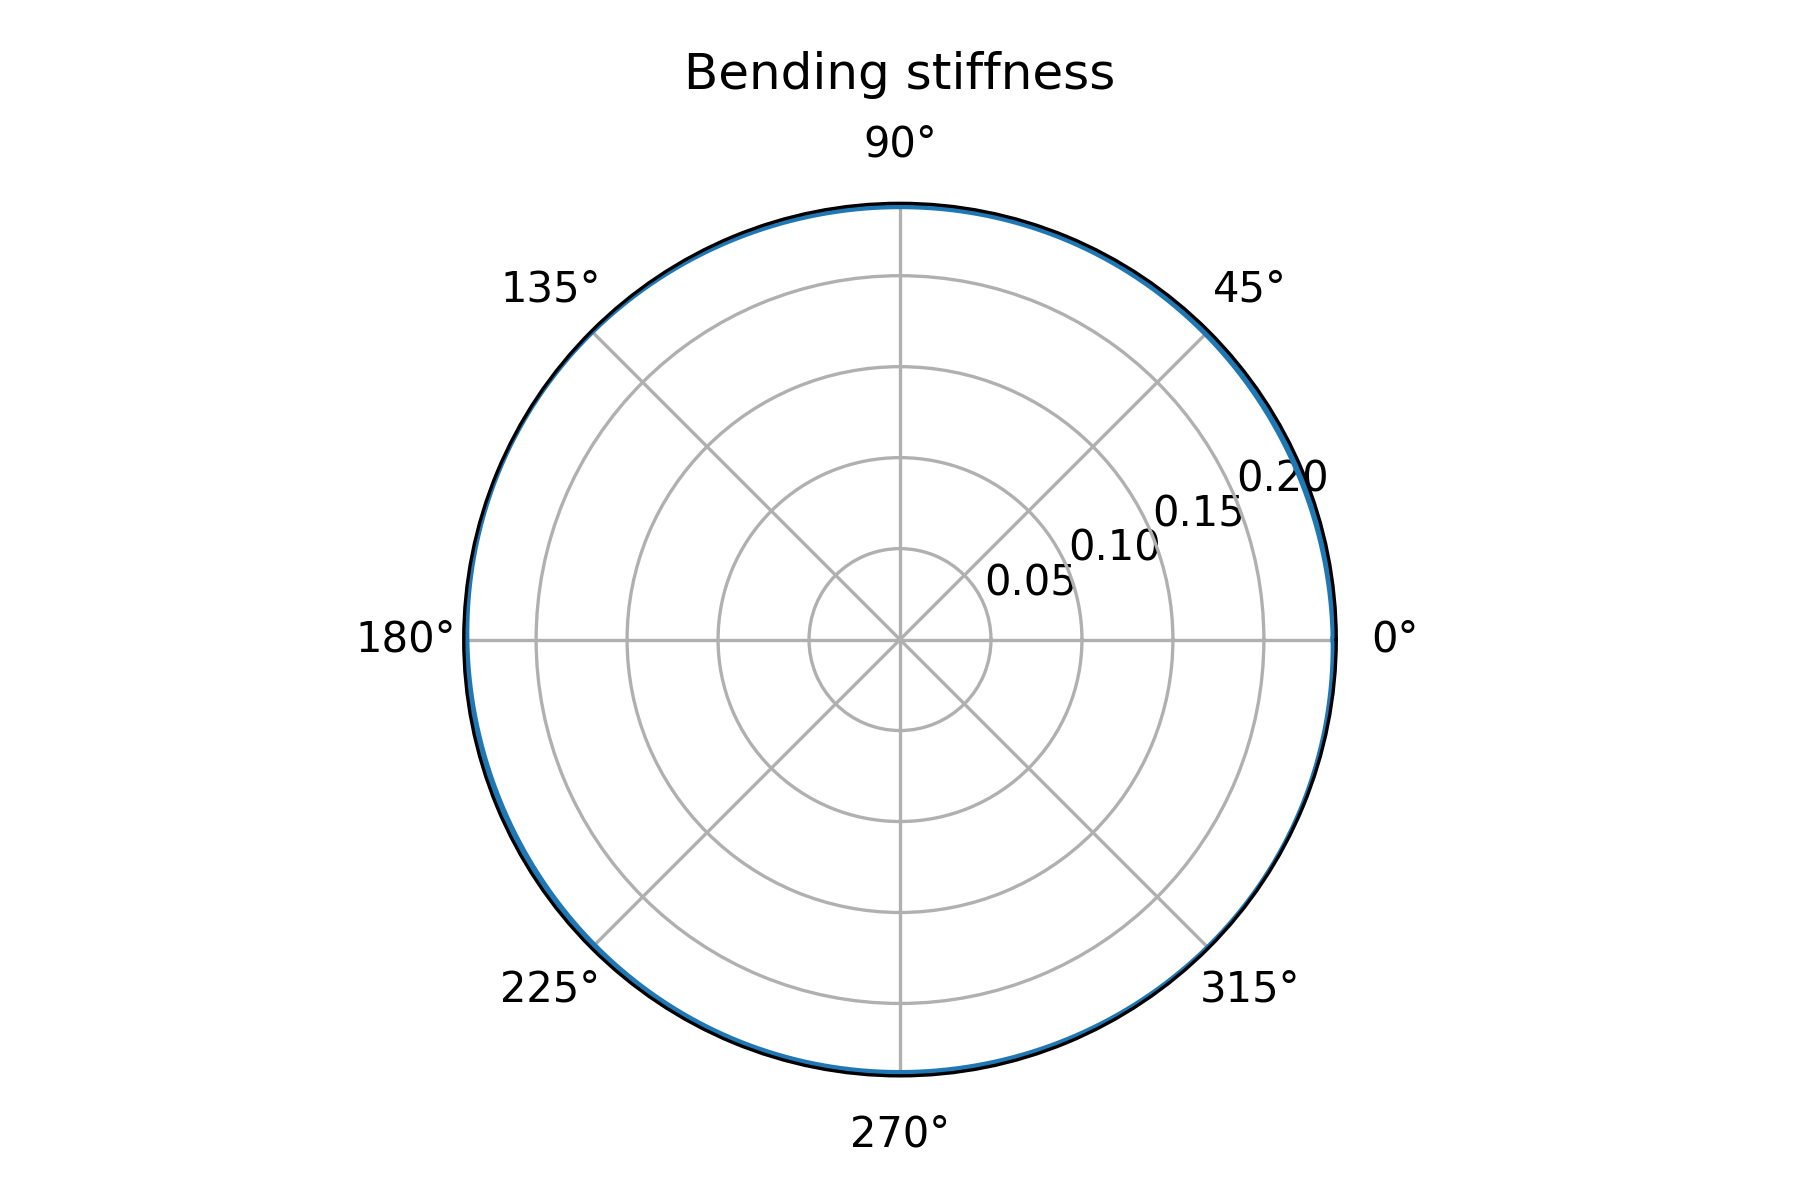

In [27]:
from IPython.display import Image
Image(filename="{}/stiffness_{}_{}.png".format(result_folder, name, variable)) 

In [28]:
min(stiffness_values), max(stiffness_values)

(0.23749595510071508, 0.2397811436527465)

In [29]:
(min(stiffness_values) - max(stiffness_values)) / min(stiffness_values)

-0.009622010408818679

In [ ]:
min(stiffness_values), max(stiffness_values)

In [ ]:
(0.23749595434540235 - 0.23746291987139068) / 0.23746291987139068

In [ ]:
np.argmin(stiffness_values)

In [ ]:
sampled_alphas[np.argmin(stiffness_values)] / np.pi * 180

In [ ]:
import periodic_simulation_setup

In [ ]:
render = viewer.offscreenRenderer(1000, 1000)
render.render()
render.save("{}/{}_render_{}_{}.png".format(result_folder, '', name, variable))

In [ ]:
import periodic_simulation_setup

In [ ]:
points = periodic_simulation_setup.visualize_average_deformation_gradient(ipu, 100, plot_max_r=1, plot_min_r=0, show_figure=True, filename = "{}/average_deformation_gradient_{}_{}.png".format(result_folder, name, variable))

In [ ]:
betas = np.linspace(0, 2 * np.pi, 1000)

In [ ]:
ipu.set_alpha(1.5)

In [ ]:
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = 0)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, 0, ipu.getStretchingStiffnessFixedVars())

In [ ]:
plot_min_r = 0
plot_max_r = None
r = list(stretchingStiffness)
# + list(stretchingStiffness)
# theta = list(sampled_alpha) + list(np.pi + np.array(sampled_alpha))
theta = list(betas)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta, r)
ax.set_rmax(max(stretchingStiffness) if plot_max_r is None else plot_max_r)
ax.set_rmin(min(stretchingStiffness) - 0.2 * (max(stretchingStiffness) - min(stretchingStiffness)) if plot_min_r is None else plot_min_r)
# ax.set_rticks([0.5, 1, 1.5, 2])  # Less radial ticks
# ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
ax.grid(True)

ax.set_title("Stretching stiffness", va='bottom')
plt.tight_layout()
plt.savefig("{}/stretching_stiffness_{}_{}.png".format(result_folder, name, 49), dpi = 300) 

In [ ]:
np.min(stretchingStiffness), np.max(stretchingStiffness)

In [ ]:
import fd_validation

In [ ]:
# az_ipu.ipu.sheet.setUseTensionFieldEnergy(False)

In [ ]:
# bs_obj = periodic_simulation_setup.bending_stiffness_class(az_ipu, az_ipu.ipu.sheet, az_optimizer, az_viewer, fixedVars = [])

# bs_obj.setVars(bs_obj.getVars())

# fd_validation.secondDerivativeConvergencePlot(bs_obj, epsilons = np.logspace(-6, -2, 50))